<a href="https://colab.research.google.com/github/alperdinceler/Machine-learning/blob/main/karar_a%C4%9Fac%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Gerekli kütüphaneleri içe aktar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Veriyi yükle
df = pd.read_csv('/content/drug200.csv')
print(f"Veri seti boyutu: {df.shape}")
print(f"Sınıf dağılımı:\n{df['Drug'].value_counts()}")

Veri seti boyutu: (200, 6)
Sınıf dağılımı:
Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [ ]:
# Özellikler (X) ve hedef (y) ayrımı
X = df.drop('Drug', axis=1)
y = df['Drug']

print(f"Özellik matrisi boyutu: {X.shape}")
print(f"Hedef vektörü boyutu: {y.shape}")

Özellik matrisi boyutu: (200, 5)
Hedef vektörü boyutu: (200,)


In [ ]:
# Eğitim ve test setlerine ayır (%70 eğitim, %30 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape}")
print(f"Test seti: {X_test.shape}")

Eğitim seti: (140, 5)
Test seti: (60, 5)


In [ ]:
# Decision Tree modelini oluştur ve eğit

# Kategorik özellikleri One-Hot Encoding ile sayısal formata dönüştür
X_train_encoded = pd.get_dummies(X_train, columns=['Sex', 'BP', 'Cholesterol'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['Sex', 'BP', 'Cholesterol'], drop_first=True)

model = DecisionTreeClassifier(
    criterion='gini',      # Bölünme kriteri: Gini impurity
    max_depth=4,           # Maksimum derinlik (overfitting'i önlemek için)
    min_samples_split=10,  # Bir düğümü bölmek için minimum örnek sayısı
    min_samples_leaf=5,    # Bir yaprak düğümdeki minimum örnek sayısı
    random_state=42        # Tekrarlanabilirlik
)

model.fit(X_train_encoded, y_train) # Encoded verileri kullanarak modeli eğit
print("Model eğitildi.")

Model eğitildi.


In [ ]:
# Test seti üzerinde tahmin yap
y_pred = model.predict(X_test_encoded)

# Model başarımını değerlendir
accuracy = accuracy_score(y_test, y_pred)
print(f"Doğruluk (Accuracy): {accuracy:.4f}")
print()

# Detaylı sınıflandırma raporu
print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=y.unique()))

Doğruluk (Accuracy): 0.9833

Sınıflandırma Raporu:
              precision    recall  f1-score   support

       drugY       0.88      1.00      0.93         7
       drugC       1.00      0.80      0.89         5
       drugX       1.00      1.00      1.00         5
       drugA       1.00      1.00      1.00        16
       drugB       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



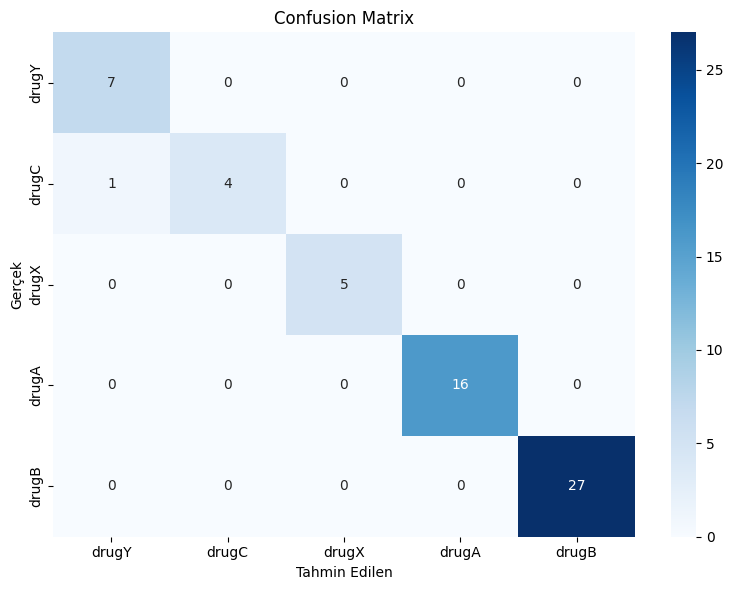

In [ ]:
# Karışıklık matrisi (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=y.unique(),
            yticklabels=y.unique())
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

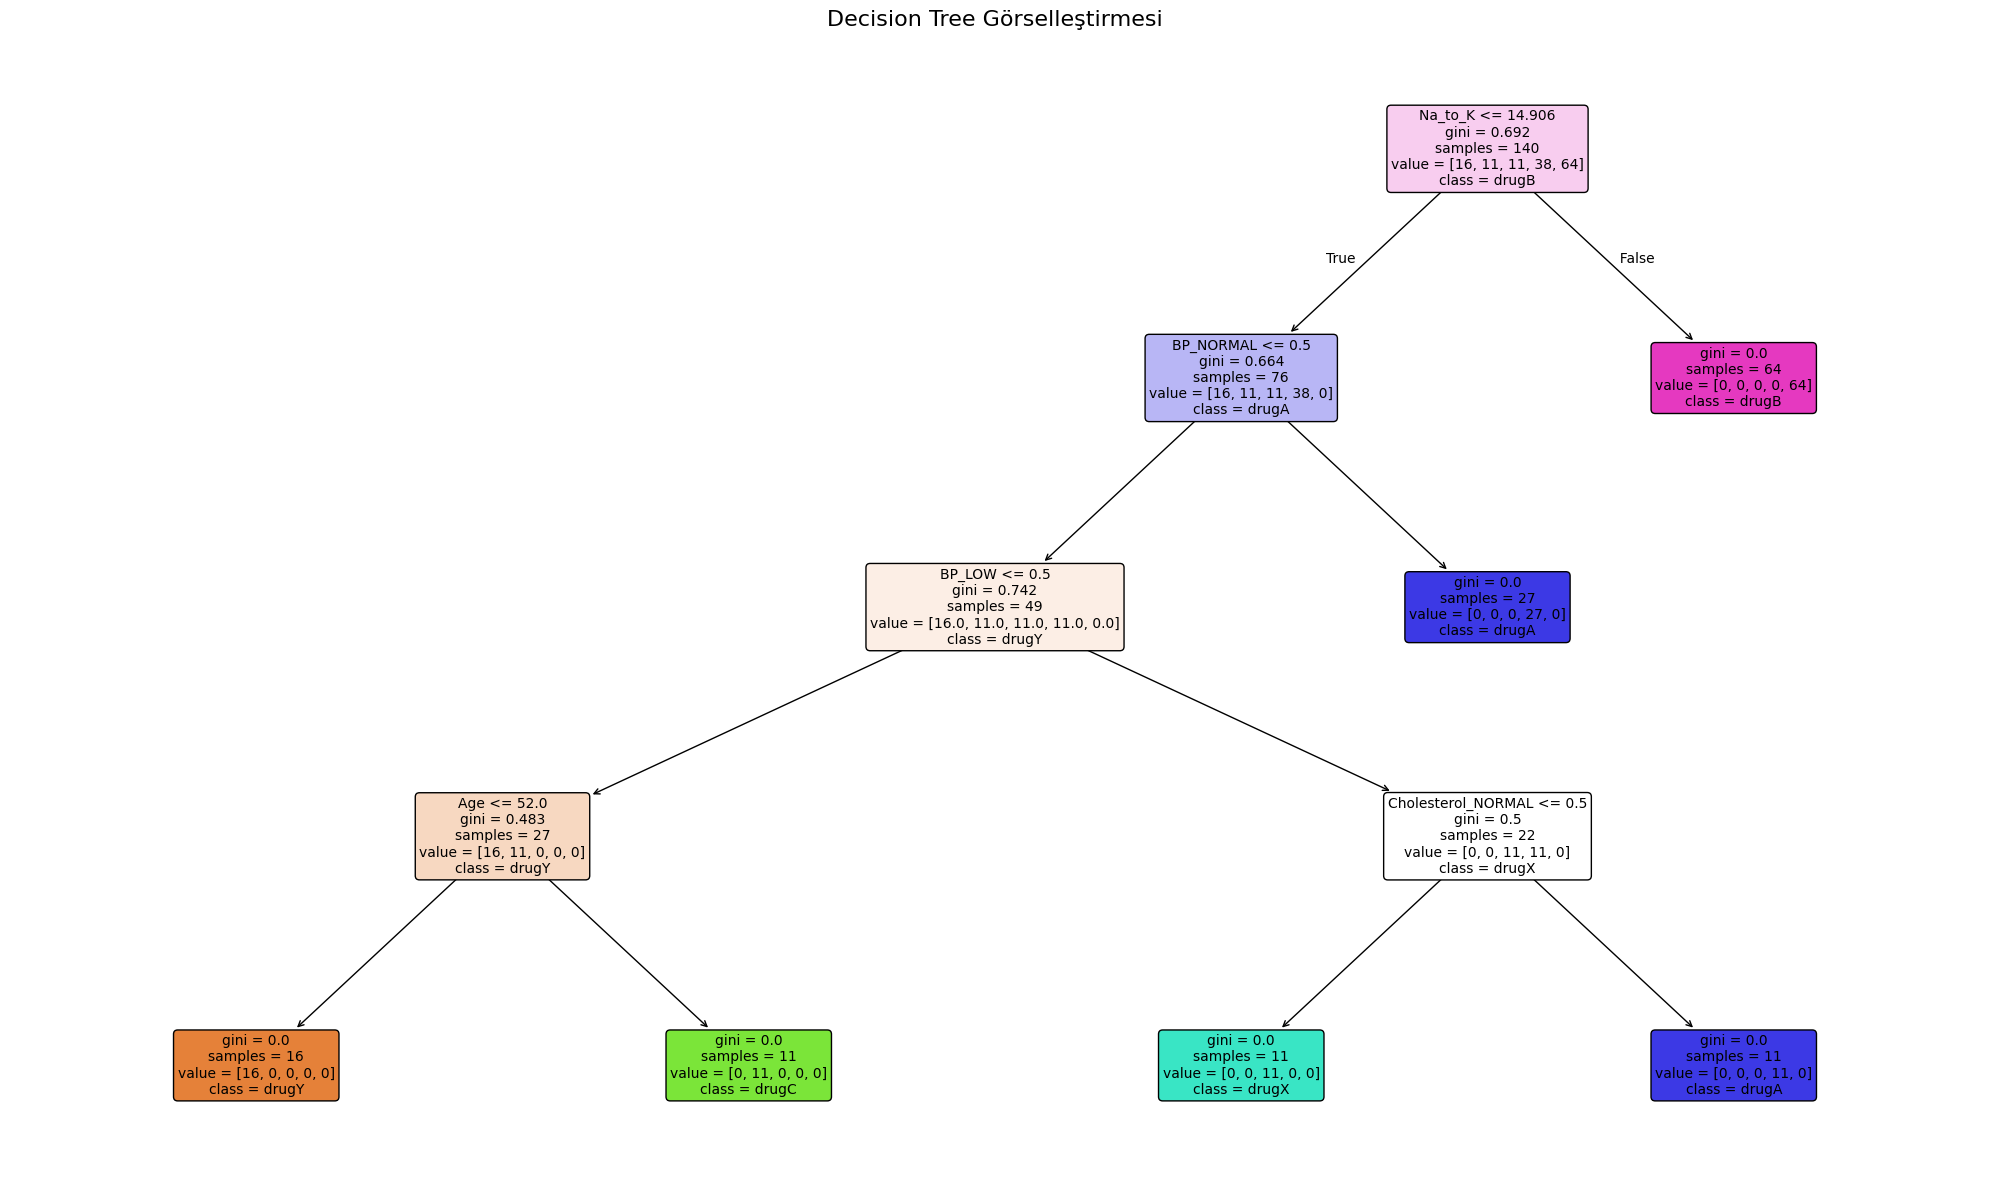

In [ ]:
# Decision Tree ağacını görselleştir
plt.figure(figsize=(20, 12))
plot_tree(
    model,
    feature_names=X_train_encoded.columns, # Use encoded feature names
    class_names=y.unique(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Görselleştirmesi', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Metinsel olarak karar ağacını görüntüle
tree_rules = export_text(
    model,
    feature_names=list(X_train_encoded.columns), # Use encoded feature names
    spacing=3
)
print(tree_rules)

|--- Na_to_K <= 14.91
|   |--- BP_NORMAL <= 0.50
|   |   |--- BP_LOW <= 0.50
|   |   |   |--- Age <= 52.00
|   |   |   |   |--- class: drugA
|   |   |   |--- Age >  52.00
|   |   |   |   |--- class: drugB
|   |   |--- BP_LOW >  0.50
|   |   |   |--- Cholesterol_NORMAL <= 0.50
|   |   |   |   |--- class: drugC
|   |   |   |--- Cholesterol_NORMAL >  0.50
|   |   |   |   |--- class: drugX
|   |--- BP_NORMAL >  0.50
|   |   |--- class: drugX
|--- Na_to_K >  14.91
|   |--- class: drugY



En Önemli 10 Özellik:
              feature  importance
1             Na_to_K    0.479234
4           BP_NORMAL    0.145348
0                 Age    0.134581
3              BP_LOW    0.127285
5  Cholesterol_NORMAL    0.113553
2               Sex_M    0.000000


/tmp/ipykernel_4727/2085025290.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10),


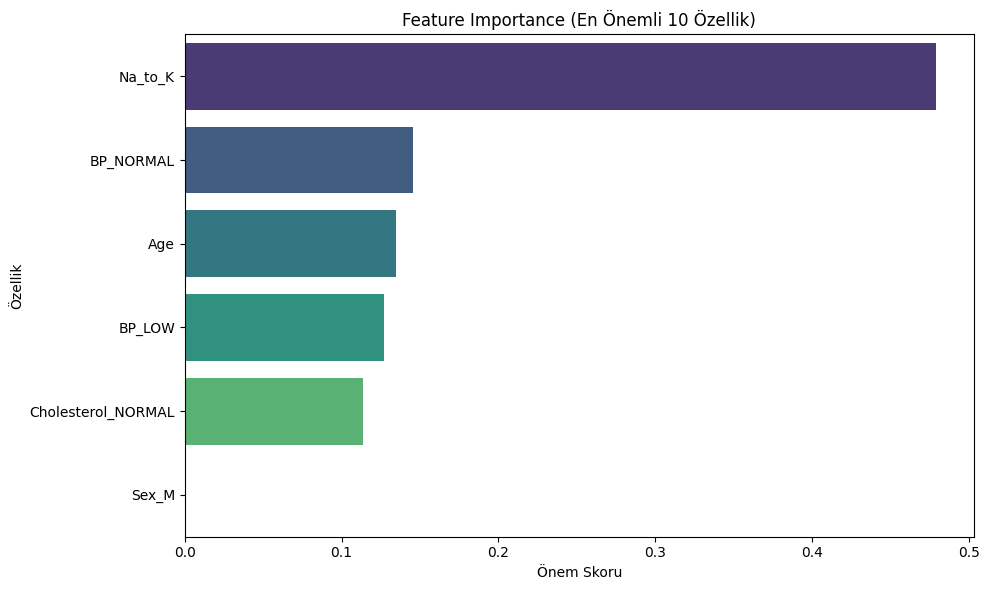

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("En Önemli 10 Özellik:")
print(feature_importance.head(10))

# Görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10),
            x='importance', y='feature',
            palette='viridis')
plt.title('Feature Importance (En Önemli 10 Özellik)')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

In [ ]:
# Modelin overfitting kontrolü için eğitim ve test doğruluklarını karşılaştır
train_accuracy = model.score(X_train_encoded, y_train)
test_accuracy = model.score(X_test_encoded, y_test)

print(f"Eğitim Doğruluğu: {train_accuracy:.4f}")
print(f"Test Doğruluğu:   {test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.1:
    print("⚠️  Model overfitting yapıyor olabilir (eğitim-test farkı > %10).")
elif train_accuracy - test_accuracy > 0.05:
    print("⚠️  Hafif overfitting olabilir.")
else:
    print("✓  Model genellemesi iyi (overfitting yok).")

Eğitim Doğruluğu: 1.0000
Test Doğruluğu:   0.9833
✓  Model genellemesi iyi (overfitting yok).


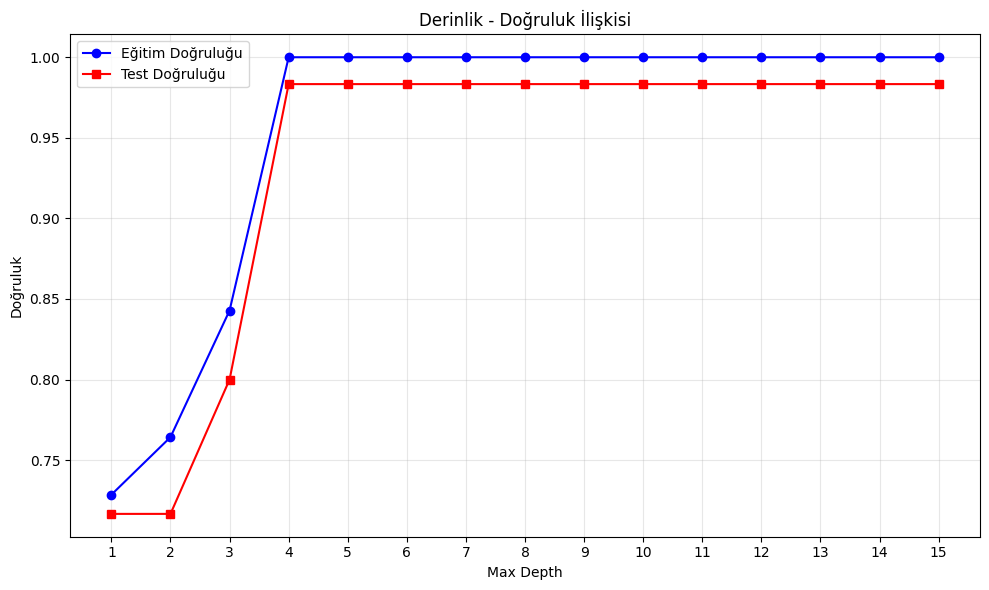

In [ ]:
# Farklı max_depth değerleri ile model karşılaştırması
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        criterion='gini',
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    dt.fit(X_train_encoded, y_train)
    train_scores.append(dt.score(X_train_encoded, y_train))
    test_scores.append(dt.score(X_test_encoded, y_test))

# Görselleştir
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'b-o', label='Eğitim Doğruluğu')
plt.plot(depths, test_scores, 'r-s', label='Test Doğruluğu')
plt.xlabel('Max Depth')
plt.ylabel('Doğruluk')
plt.title('Derinlik - Doğruluk İlişkisi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()